# 1. Data Loading
---
This notebook is intended to be run both locally and on kaggle. Therefore, it needs accomodates the different data sources when loading the csvs. Before handling the data, imports will all be coalesced into a specified subsection.



## 1.1 Imports

In [ ]:
"""Student health risk prediction notebook."""
import os
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, balanced_accuracy_score


# 1.2 Data loading

In [2]:
# 1. Automatically detect the environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # Settings optimized for Kaggle's NVIDIA GPUs
    TREE_METHOD = "hist"  # XGBoost
    DEVICE_TYPE = "cuda"  # XGBoost / LightGBM
    CAT_TASK_TYPE = "GPU"  # CatBoost
    print("Environment: Kaggle (NVIDIA CUDA Enabled)")
else:
    # Settings optimized for my MacBook Pro M5 Pro
    TREE_METHOD = "hist"  # XGBoost (Uses Metal/MPS natively via hist)
    DEVICE_TYPE = "gpu"  # LightGBM (Compiled with OpenCL/MPS support)
    CAT_TASK_TYPE = "CPU"  # CatBoost (Mac GPU support is experimental; CPU is faster)
    print("Environment: Local Mac (M5 Pro GPU Optimized)")

Environment: Local Mac (M5 Pro GPU Optimized)


In [3]:
def load_data():
    """
    try to load the data from the local directory, if not found, load it from the Kaggle dataset.
    Output the three dataframes: train, test, and submission.
    """

    if IS_KAGGLE:
        # check if the data files are in kaggle direcotry
        # /kaggle/input/competitions/playground-series-s6e7
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/train.csv"
        )
        test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
        submission = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
        )
        print("Data loaded successfully from kaggle input directory.")
    else:
        print("Trying to load data from local directory...")
        # Load data from local directory
        data_dir = os.getcwd() + "/data/"
        train = pd.read_csv(data_dir + "train.csv")
        test = pd.read_csv(data_dir + "test.csv")
        submission = pd.read_csv(data_dir + "sample_submission.csv")
        print("Data loaded successfully from local directory.")

    return train, test, submission

In [4]:
train_df, test_df, submission_df = load_data()

Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data exploration
---
Having organised the data into dataframes that can be explored and prepared for preprocessing, the necessary quality checks can be done. In this section, we will explore the data for missing values, extreme values and mislabelled data types. 

## 2.1 Check for missing values/null values

In [5]:
def check_missing_values(df):
    """
    Check for missing values in the dataframe and print the count of missing values for each column.
    """
    temp_df = df.copy()
    # check if the dataframe is empty
    if temp_df.empty:
        print("The dataframe is empty. No missing values to check.")
        return
    # check that the dataframe has missing values
    if temp_df.isnull().sum().sum() == 0:
        print("The dataframe has no missing values.")
        return
    # Iterate through each column and check the number of missing values
    for column in temp_df.columns:
        missing_count = temp_df[column].isnull().sum()
        if missing_count > 0:
            # print column name
            # number of missing values againts total number of rows in the column
            total_rows = temp_df.shape[0]
            print(
                f"{column:<25}"
                f"Missing Values: {missing_count:<10}"
                f"Total Rows: {total_rows:<10}"
                f"Percentage Missing: {missing_count / total_rows * 100:.2f}%"
            )

In [6]:
check_missing_values(train_df)


sleep_duration           Missing Values: 75999     Total Rows: 690088    Percentage Missing: 11.01%
heart_rate               Missing Values: 7833      Total Rows: 690088    Percentage Missing: 1.14%
bmi                      Missing Values: 13898     Total Rows: 690088    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 52853     Total Rows: 690088    Percentage Missing: 7.66%
step_count               Missing Values: 13916     Total Rows: 690088    Percentage Missing: 2.02%
exercise_duration        Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
water_intake             Missing Values: 43477     Total Rows: 690088    Percentage Missing: 6.30%
diet_type                Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
stress_level             Missing Values: 82811     Total Rows: 690088    Percentage Missing: 12.00%
sleep_quality            Missing Values: 58331     Total Rows: 690088    Percentage Missing: 8.45%
physical

In [7]:
check_missing_values(test_df)

sleep_duration           Missing Values: 32571     Total Rows: 295753    Percentage Missing: 11.01%
heart_rate               Missing Values: 3357      Total Rows: 295753    Percentage Missing: 1.14%
bmi                      Missing Values: 5956      Total Rows: 295753    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 22652     Total Rows: 295753    Percentage Missing: 7.66%
step_count               Missing Values: 5964      Total Rows: 295753    Percentage Missing: 2.02%
exercise_duration        Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
water_intake             Missing Values: 18633     Total Rows: 295753    Percentage Missing: 6.30%
diet_type                Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
stress_level             Missing Values: 35490     Total Rows: 295753    Percentage Missing: 12.00%
sleep_quality            Missing Values: 24999     Total Rows: 295753    Percentage Missing: 8.45%
physical

Even though there is missing data in the train dataset. The presence of missing data in the test data could mean mimicry of real world challenges face, therefore the next sections will explore ways to elegantly form predictions with the presence of missing data.

## 2.2 Class imbalance check

In [8]:
def check_class_imbalance(df):
    """
    Check for class imbalance.
    Plots distribution of target variables.
    target column is assumed to always be health_condition as from competition details.

    Input-
    df: pandas dataframe

    Output-
    None

    """

    # check if the dataframe is empty
    if df.empty:
        print("The dataframe is empty. No class imbalance to check.")
        return

    # check if the target column exists
    if "health_condition" not in df.columns:
        print("The target column 'health_condition' does not exist in the dataframe.")
        return

    # check if the target column has more than one class
    if df["health_condition"].nunique() <= 1:
        print(
            "The target column 'health_condition' has only one class. No class imbalance to check."
        )
        return

    # Plot grid of multiple different plots to visualize class imbalance
    plt.figure(figsize=(15, 10))
    # Add title to the grid of plots
    plt.suptitle("Health Condition Imbalance Visualization", fontsize=16)

    # Plot horizontal bar chart of health condition with counts of samples
    plt.subplot(2, 2, 1)
    ax = sns.countplot(
        data=df,
        y="health_condition",
        order=df["health_condition"].value_counts().index,
        hue="health_condition",
        palette=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    # add value counts to the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type="center",
        )

    # Plot pie chart of target variable with percentage of samples in each class
    plt.subplot(2, 2, 2)
    df["health_condition"].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    plt.title("Pie Chart of Health Condition")
    # add legend to the pie chart and place it outside the pie chart
    plt.legend(
        labels=df["health_condition"].value_counts().index,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
    )

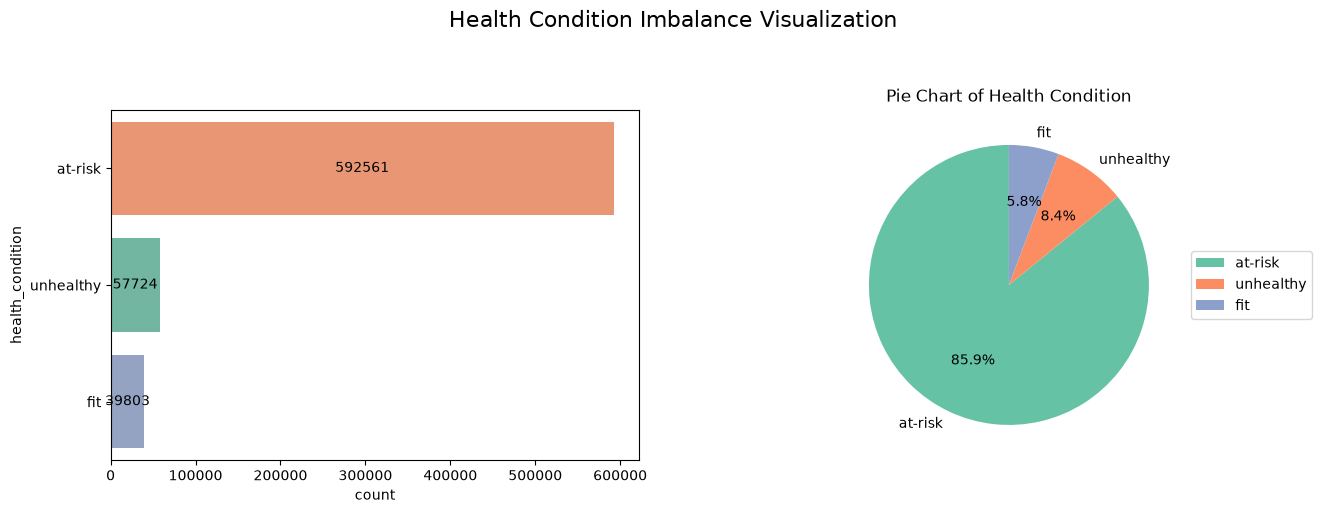

In [9]:
check_class_imbalance(train_df)

From the above, it can be seen that the dataset is imbalanced. `At-risk` label has around *85%* of the samples while `fit` and `unhealthy` are at *5.7%* and *8.5%* respectively. 

# 3. Data Preprocessing

## 3.1 Addressing the `id` column 
The `id` column is of no use in prediction and could possible be detrimental to the accuracy of the predictions. To prevent any negative effects setting the columns as the index would indicate to the model and processing functions that the column should be excluded.

In [10]:
train_df.set_index("id", inplace=True)
test_df.set_index("id", inplace=True)

## 3.2 Encoding categorical columns

In [11]:
# encoding the target variable
le = LabelEncoder()
y_train = le.fit_transform(train_df["health_condition"])

# Convert categorical string features to pandas 'category' data type
categorical_cols = train_df.select_dtypes(include=["object", "string"]).columns

for col in categorical_cols:
    if col != "health_condition":  # Skip target since it's already separated
        train_df[col] = train_df[col].astype("category")
        test_df[col] = test_df[col].astype("category")

# Separate features from the training set
X_train = train_df.drop(columns=["health_condition"])

## 3.3 Validation split

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,  # Crucial for the imbalanced dataset
    random_state=42,
)

# 4. Model

## 4.1 Model Training

In [13]:
# Compute sample weights to counter the 85% / 8.5% / 5.7% class imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",  # Use 'multi:softprob' if you need probabilities
    num_class=3,
    tree_method="hist",
    enable_categorical=True,
    missing=np.nan,
    eval_metric="mlogloss",  # Standard evaluation metric for multi-class
    random_state=42,
    early_stopping_rounds=50,  # Stops training if validation score doesn't improve
)

# Fit the model using the validation set
xgb_model.fit(
    X_tr,
    y_tr,
    sample_weight=sample_weights,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=50,  # Prints out the validation score every 50 trees
)

[0]	validation_0-mlogloss:0.77020	validation_1-mlogloss:0.77057
[50]	validation_0-mlogloss:0.25022	validation_1-mlogloss:0.25794
[61]	validation_0-mlogloss:0.24878	validation_1-mlogloss:0.25837


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( 

## 4.2 Model Evaluation

Validation Balanced Accuracy: 0.9498
------------------------------


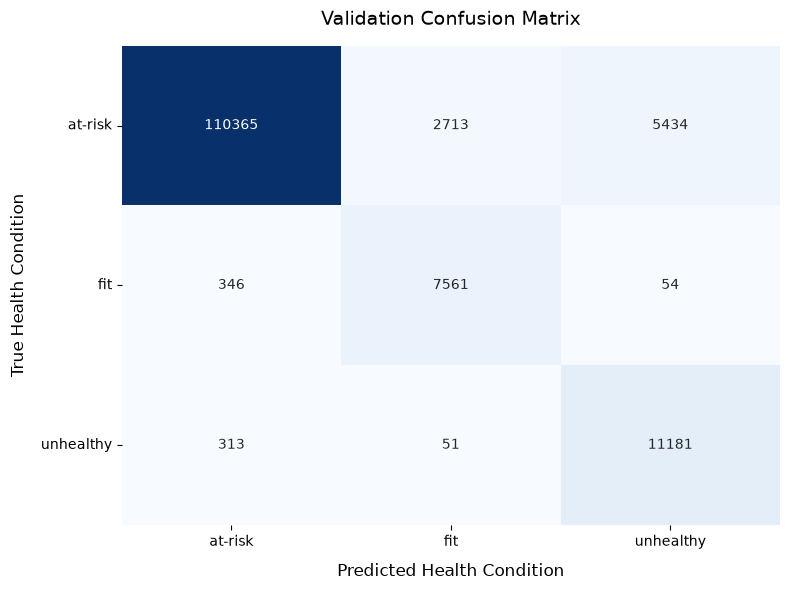

In [14]:
# Generate predictions on the validation set
y_pred = xgb_model.predict(X_val)

# Calculate Balanced Accuracy
bal_acc = balanced_accuracy_score(y_val, y_pred)
print(f"Validation Balanced Accuracy: {bal_acc:.4f}")
print("-" * 30)

# Generate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Visualize with a seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,  # Displays the raw numbers inside the cells
    fmt="d",  # Formats the annotations as integers
    cmap="Blues",  # Uses a clean blue color palette
    cbar=False,  # Hides the colorbar for a cleaner look
    xticklabels=le.classes_,  # Maps encoded integers back to string labels
    yticklabels=le.classes_,
)

# Optimize plot aesthetics
plt.title("Validation Confusion Matrix", fontsize=14, pad=15)
plt.xlabel("Predicted Health Condition", fontsize=12, labelpad=10)
plt.ylabel("True Health Condition", fontsize=12, labelpad=10)
plt.yticks(rotation=0)  # Keeps y-axis labels horizontal
plt.tight_layout()
plt.show()

In [15]:
# Format the Confusion Matrix as a text-friendly DataFrame
cm_text = pd.DataFrame(
    cm,
    index=[f"True: {cls}" for cls in le.classes_],
    columns=[f"Pred: {cls}" for cls in le.classes_],
)

print("--- The Concussion Matrix (Text Version) ---")
print(cm_text)
print("\n" + "=" * 45 + "\n")

# 2. Generate a full classification report for detailed metrics
print("--- Classification Report ---")
report = classification_report(y_val, y_pred, target_names=le.classes_)
print(report)

--- The Concussion Matrix (Text Version) ---
                 Pred: at-risk  Pred: fit  Pred: unhealthy
True: at-risk           110365       2713             5434
True: fit                  346       7561               54
True: unhealthy            313         51            11181


--- Classification Report ---
              precision    recall  f1-score   support

     at-risk       0.99      0.93      0.96    118512
         fit       0.73      0.95      0.83      7961
   unhealthy       0.67      0.97      0.79     11545

    accuracy                           0.94    138018
   macro avg       0.80      0.95      0.86    138018
weighted avg       0.95      0.94      0.94    138018



# 5.Submission

In [ ]:
# Generate predictions on the test dataset
# Note: Ensure test_df has undergone the exact same categorical casting as train_df
test_predictions = xgb_model.predict(test_df)

# Inverse transform the numerical predictions back to string labels
test_pred_labels = le.inverse_transform(test_predictions)

# Construct the submission DataFrame
# We pull the 'id' directly from the test_df index
submission_df = pd.DataFrame(
    {"id": test_df.index, "health_condition": test_pred_labels}
)

# 4. Save the DataFrame to a CSV file
# index=False prevents pandas from writing the DataFrame's row indices to the file
submission_filename = "submission.csv"
submission_df.to_csv(submission_filename, index=False)

print(f"Submission successfully saved to {submission_filename}!")
print("-" * 30)
print(submission_df.head())

Submission successfully saved to submission.csv!
------------------------------
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
